# Baseline AI Agent Evaluation

Loads `Qwen2.5-1.5B-Instruct` and runs it as an agent against
`AIResponseEvalEnvironment`, then saves per-task scores and a plot.
This notebook does **not** train the model — it only measures how the
untrained agent performs on the env's evaluation tasks.

| Step | What happens |
|---|---|
| 1 | Install dependencies (inference-only) |
| 2 | Configure model name and paths |
| 3 | Clone and import local environment |
| 4 | Define environment wrapper (direct Python — no HTTP) |
| 5 | Load Qwen2.5-1.5B-Instruct with Unsloth (4-bit) |
| 6 | Run agent for 20 episodes (real model.generate calls) |
| 7 | Save scores to JSON |
| 8 | Plot baseline performance |

## Cell 1 — Install dependencies

In [1]:
# Install required packages (inference-only)
!pip install unsloth transformers accelerate bitsandbytes -q
!pip install matplotlib numpy pandas -q
!pip install 'openenv-core[core]>=0.2.1' -q

# Clone the eval environment from HF Spaces
import os, sys
!git clone https://huggingface.co/spaces/rsaibhargav/ai-response-eval-env /content/ai_response_eval_env -q 2>/dev/null || echo 'Already cloned'
!pip install -r /content/ai_response_eval_env/requirements.txt -q

sys.path.insert(0, '/content')
sys.path.insert(0, '/content/ai_response_eval_env')
os.chdir('/content/ai_response_eval_env')
print('Dependencies installed ✓')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 115.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 95.0 MB/s eta 0:

## Cell 2 — Configuration

In [3]:
import os

# Agent under evaluation
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

# Evaluation settings
NUM_EPISODES      = 20
STEPS_PER_EPISODE = 30
MAX_NEW_TOKENS    = 40

# Output paths
os.makedirs('baseline_results', exist_ok=True)
RESULTS_JSON = 'baseline_results/baseline_scores.json'
PLOT_FILE    = 'baseline_results/baseline_plot.png'

print(f'Model    : {MODEL_NAME}')
print(f'Episodes : {NUM_EPISODES}')
print(f'Results  -> {RESULTS_JSON}')

Model    : Qwen/Qwen2.5-1.5B-Instruct
Episodes : 20
Results  -> baseline_results/baseline_scores.json


## Cell 3 — Import local environment

In [4]:
import sys, os
sys.path.insert(0, '/content')
sys.path.insert(0, '/content/ai_response_eval_env')
os.chdir('/content/ai_response_eval_env')

from server.ai_response_eval_environment import AIResponseEvalEnvironment, TASK_TYPES, TASK_INSTRUCTIONS
from models import AIResponseEvalAction

print('Environment imported OK')
print('Available tasks:', list(TASK_TYPES.values()))

Environment imported OK
Available tasks: ['correctness_check', 'tone_appropriateness', 'multi_dimensional', 'conversation_coherence', 'adversarial_check']


## Cell 4 — Define environment wrapper

In [5]:
class AIResponseEvalToolEnv:
    """
    Wrapper for the evaluation environment.
    Uses direct Python calls (no HTTP).
    """
    def __init__(self):
        self._env    = AIResponseEvalEnvironment()
        self._obs    = self._env.reset()
        self.reward  = 0.0
        self._done   = False

    def _obs_to_str(self, obs) -> str:
        return (
            f'TASK: {obs.task_type} | DIFFICULTY: {obs.difficulty}\n'
            f'INSTRUCTIONS: {obs.problem_description}\n'
            f'--- SCENARIO ---\n{obs.test_case_input}\n--- END ---'
        )

    def reset(self, **kwargs) -> str:
        """Start a new evaluation episode."""
        self.reward = 0.0
        self._done  = False
        self._obs   = self._env.reset()
        return self._obs_to_str(self._obs)

    def evaluate(self, answer: str) -> str:
        """Submit evaluation verdict for the current scenario."""
        if self._done:
            return 'Episode already done. Call reset() to start a new one.'
        obs = self._env.step(AIResponseEvalAction(answer=answer))
        step_reward = float(obs.partial_credit or 0.0)
        self.reward += step_reward
        self._done = bool(obs.done)
        if self._done:
            return f'Episode done. Total reward: {self.reward:.3f}. Last: {obs.feedback}'
        return (
            f'Feedback: {obs.feedback} (step reward={step_reward:.2f})\n'
            + self._obs_to_str(obs)
        )

# Smoke test
env_test = AIResponseEvalToolEnv()
prompt = env_test.reset()
print('✓ Environment reset OK')
print('First task:', prompt.split('\n')[0])

✓ Environment reset OK
First task: TASK: correctness_check | DIFFICULTY: easy


## Cell 5 — Load the agent (Qwen2.5-1.5B-Instruct)

In [6]:
from unsloth import FastLanguageModel

max_seq_length = 700

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

# Inference mode — no training in this notebook
FastLanguageModel.for_inference(model)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Loaded {MODEL_NAME} (untrained baseline). Ready to generate.')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Loaded Qwen/Qwen2.5-1.5B-Instruct (untrained baseline). Ready to generate.


## Cell 6 — Run agent for 20 episodes (real model.generate calls)

In [7]:
import torch
from datetime import datetime

SYSTEM_PROMPT = (
    'You are an expert AI response evaluator. '
    'You receive an evaluation scenario and must reply with the verdict ONLY, '
    'in the exact format the task requires. No extra commentary, no quotes, '
    'no code fences — just the verdict line.'
)

# Reference task names — used only for the per-task stats table.
TASK_NAMES = [
    'correctness_check',
    'tone_appropriateness',
    'multi_dimensional',
    'conversation_coherence',
    'adversarial_check',
]

def generate_answer(prompt_text: str) -> str:
    """Run one model.generate call and return the extracted verdict line."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt_text},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt',
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    new_tokens = out[0][inputs.shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Take the first non-empty line, strip stray quotes/backticks
    for line in raw.splitlines():
        line = line.strip().strip('`').strip('"').strip("'")
        if line:
            return line
    return raw


def run_baseline_evaluation(n_episodes=NUM_EPISODES):
    results = {
        'timestamp':    datetime.now().isoformat(),
        'model':        MODEL_NAME,
        'num_episodes': n_episodes,
        'episodes':     [],
        'task_stats':   {},
    }
    episode_rewards = []
    task_hits, task_totals, task_rewards = {}, {}, {}

    for ep in range(n_episodes):
        env = AIResponseEvalToolEnv()
        prompt = env.reset()
        episode_steps = []

        for step in range(STEPS_PER_EPISODE):
            if env._done:
                break
            task = env._obs.task_type if env._obs else 'correctness_check'
            answer = generate_answer(prompt)

            env._obs = env._env.step(AIResponseEvalAction(answer=answer))
            step_reward = float(env._obs.partial_credit or 0.0)
            env.reward += step_reward

            task_hits[task]    = task_hits.get(task, 0) + int(step_reward >= 0.9)
            task_totals[task]  = task_totals.get(task, 0) + 1
            task_rewards.setdefault(task, []).append(step_reward)

            episode_steps.append({
                'step':     step,
                'task':     task,
                'answer':   answer,
                'reward':   step_reward,
                'feedback': env._obs.feedback,
            })

            env._done = bool(env._obs.done)
            prompt = env._obs_to_str(env._obs) if not env._done else ''

        episode_rewards.append(env.reward)
        results['episodes'].append({
            'episode':      ep + 1,
            'total_reward': env.reward,
            'steps':        len(episode_steps),
            'steps_detail': episode_steps,
        })
        print(f'Episode {ep+1:2d}/{n_episodes} | steps={len(episode_steps):2d} | reward={env.reward:.3f}')

    for task in TASK_NAMES:
        n = task_totals.get(task, 0)
        if n:
            rewards = task_rewards.get(task, [])
            results['task_stats'][task] = {
                'accuracy':   round(100 * task_hits.get(task, 0) / n, 1),
                'avg_reward': round(sum(rewards) / len(rewards), 3),
                'hits':       task_hits.get(task, 0),
                'total':      n,
            }

    results['overall'] = {
        'avg_episode_reward': round(sum(episode_rewards)/len(episode_rewards), 3) if episode_rewards else 0,
        'min_episode_reward': round(min(episode_rewards), 3) if episode_rewards else 0,
        'max_episode_reward': round(max(episode_rewards), 3) if episode_rewards else 0,
        'episode_rewards':    [round(r, 3) for r in episode_rewards],
    }
    return results


print(f'Running baseline evaluation: {NUM_EPISODES} episodes x up to {STEPS_PER_EPISODE} steps...')
baseline_results = run_baseline_evaluation()
print(f'\n✓ Done. Avg episode reward: {baseline_results["overall"]["avg_episode_reward"]:.3f}')

Running baseline evaluation: 20 episodes x up to 30 steps...


Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

Episode  1/20 | steps=24 | reward=13.810


Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Episode  2/20 | steps=24 | reward=13.800


...

Episode 18/20 | steps=24 | reward=15.810


Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Episode 19/20 | steps=24 | reward=12.720


Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Episode 20/20 | steps=24 | reward=15.180

✓ Done. Avg episode reward: 13.945


## Cell 7 — Save results to JSON

In [8]:
import json

# Save detailed results
with open(RESULTS_JSON, 'w') as f:
    json.dump(baseline_results, f, indent=2)

print(f'✓ Results saved to {RESULTS_JSON}')

# Print summary
print('\n' + '='*60)
print('BASELINE EVALUATION SUMMARY')
print('='*60)
print(f'Episodes: {baseline_results["num_episodes"]}')
print(f'Avg Episode Reward: {baseline_results["overall"]["avg_episode_reward"]:.3f}')
print(f'Min Episode Reward: {baseline_results["overall"]["min_episode_reward"]:.3f}')
print(f'Max Episode Reward: {baseline_results["overall"]["max_episode_reward"]:.3f}')
print('\nPer-Task Accuracy:')
print('-'*60)
for task, stats in baseline_results['task_stats'].items():
    print(f'{task:30s} | Accuracy: {stats["accuracy"]:6.1f}% | Avg Reward: {stats["avg_reward"]:.3f}')
print('='*60)

✓ Results saved to baseline_results/baseline_scores.json

BASELINE EVALUATION SUMMARY
Episodes: 20
Avg Episode Reward: 13.945
Min Episode Reward: 12.650
Max Episode Reward: 15.810

Per-Task Accuracy:
------------------------------------------------------------
correctness_check              | Accuracy:    0.0% | Avg Reward: 0.600
tone_appropriateness           | Accuracy:    1.7% | Avg Reward: 0.275
multi_dimensional              | Accuracy:    1.7% | Avg Reward: 0.726
conversation_coherence         | Accuracy:   11.7% | Avg Reward: 0.648


## Cell 8 — Plot baseline performance

✓ Plot saved to baseline_results/baseline_plot.png


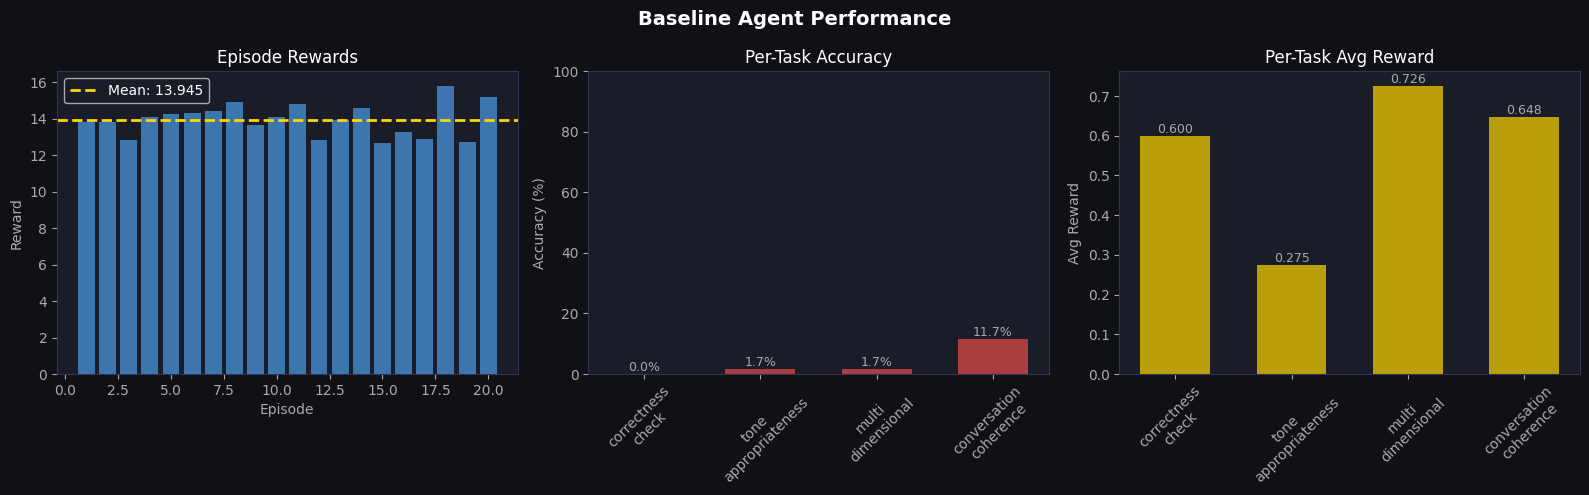

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Color scheme
BG = '#0F1117'
CARD = '#1A1D27'
BLUE = '#4C9BE8'
RED = '#E84C4C'
GOLD = '#FFD700'
GREY = '#AAAAAA'

# Data
episode_rewards  = baseline_results['overall']['episode_rewards']
task_names       = list(baseline_results['task_stats'].keys())
task_accuracies  = [baseline_results['task_stats'][t]['accuracy']   for t in task_names]
task_avg_rewards = [baseline_results['task_stats'][t]['avg_reward'] for t in task_names]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle('Baseline Agent Performance', color='white', fontsize=14, fontweight='bold')

# Plot 1: Episode rewards over episodes
ax = axes[0]
ax.set_facecolor(CARD)
episodes = list(range(1, len(episode_rewards) + 1))
ax.bar(episodes, episode_rewards, color=BLUE, alpha=0.7, width=0.8)
mean_r = np.mean(episode_rewards) if episode_rewards else 0.0
ax.axhline(y=mean_r, color=GOLD, linestyle='--', linewidth=2, label=f'Mean: {mean_r:.3f}')
ax.set_title('Episode Rewards', color='white', fontsize=12)
ax.set_xlabel('Episode', color=GREY)
ax.set_ylabel('Reward', color=GREY)
ax.tick_params(colors=GREY)
ax.legend(facecolor=CARD, labelcolor='white', loc='best')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Plot 2: Per-task accuracy
ax = axes[1]
ax.set_facecolor(CARD)
task_labels = [t.replace('_', '\n') for t in task_names]
colors = [BLUE if acc >= 50 else RED for acc in task_accuracies]
bars = ax.bar(task_labels, task_accuracies, color=colors, alpha=0.7, width=0.6)
ax.set_title('Per-Task Accuracy', color='white', fontsize=12)
ax.set_ylabel('Accuracy (%)', color=GREY)
ax.set_ylim(0, 100)
ax.tick_params(colors=GREY, axis='x', rotation=45)
ax.tick_params(colors=GREY, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', color=GREY, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Plot 3: Per-task average reward
ax = axes[2]
ax.set_facecolor(CARD)
bars = ax.bar(task_labels, task_avg_rewards, color=GOLD, alpha=0.7, width=0.6)
ax.set_title('Per-Task Avg Reward', color='white', fontsize=12)
ax.set_ylabel('Avg Reward', color=GREY)
ax.tick_params(colors=GREY, axis='x', rotation=45)
ax.tick_params(colors=GREY, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', color=GREY, fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150, facecolor=BG, bbox_inches='tight')
print(f'✓ Plot saved to {PLOT_FILE}')
plt.show()

## Summary

| Output | Location | Description |
|---|---|---|
| Detailed scores | `baseline_results/baseline_scores.json` | Episode-by-episode results |
| Performance plot | `baseline_results/baseline_plot.png` | Per-task metrics |

The agent's accuracy will likely be near 0% on most tasks — the untrained
model doesn't know the env's strict answer formats (`'correct, none'`,
`'correctness=8, tone=7, ...'`, etc.). That gap is what the GRPO training
notebook (`train_grpo_colab.ipynb`) is designed to close.